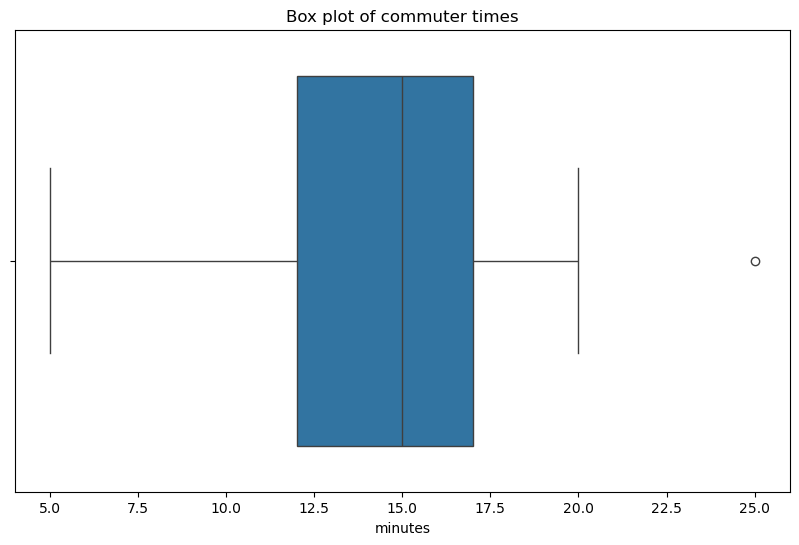

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

commuter_times = [16,8.35,17,13,15,15,5,16,25,20,20,12,10]
plt.figure(figsize = (10,6))
sns.boxplot(data=commuter_times,orient='h')
plt.title("Box plot of commuter times")
plt.xlabel("minutes")
plt.show()

In [54]:
import numpy as np
q1 = np.percentile(commuter_times,25)
q3 = np.percentile(commuter_times,75)

iqr = q3-q1

lower_bound = q1-1.5*iqr
upper_bound = q3+1.5*iqr

outliers = []

for x in commuter_times:
    if x<lower_bound or x > upper_bound:
        outliers.append(x)

print(f"Q1 = {q1}")
print(f"Q3 = {q3}")
print(outliers)

Q1 = 12.0
Q3 = 17.0
[25]


## Using SCIKIT learn's SimpleImputer to handle outliers (missing values)

In [55]:
import pandas as pd
from sklearn.impute import SimpleImputer

df = pd.read_csv("titanic.csv")
df['age_mean'] = df['age'].fillna(df['age'].mean())
df['age_median']=df['age'].fillna(df['age'].median())
df['age_mode']=df['age'].fillna(df['age'].mode()[0])
df['age_constant']= df['age'].fillna(0)

imp_mean = SimpleImputer(strategy='mean')
df['age_imputer_mean'] = imp_mean.fit_transform(df[['age']])

imp_median = SimpleImputer(strategy='median')
df['age_imputer_median'] = imp_median.fit_transform(df[['age']])

imp_mode = SimpleImputer(strategy='most_frequent')

df['age_imputer_mode'] = imp_mode.fit_transform(df[['age']])

imp_const = SimpleImputer(strategy ='constant',fill_value=0)
df['age_imputer_constant']= imp_const.fit_transform(df[['age']])
print(df[['age','age_mean','age_median','age_mode','age_constant','age_imputer_mean','age_imputer_median','age_imputer_mode','age_imputer_constant']])

      age   age_mean  age_median  age_mode  age_constant  age_imputer_mean  \
0    22.0  22.000000        22.0      22.0          22.0         22.000000   
1    38.0  38.000000        38.0      38.0          38.0         38.000000   
2    26.0  26.000000        26.0      26.0          26.0         26.000000   
3    35.0  35.000000        35.0      35.0          35.0         35.000000   
4    35.0  35.000000        35.0      35.0          35.0         35.000000   
..    ...        ...         ...       ...           ...               ...   
886  27.0  27.000000        27.0      27.0          27.0         27.000000   
887  19.0  19.000000        19.0      19.0          19.0         19.000000   
888   NaN  29.699118        28.0      24.0           0.0         29.699118   
889  26.0  26.000000        26.0      26.0          26.0         26.000000   
890  32.0  32.000000        32.0      32.0          32.0         32.000000   

     age_imputer_median  age_imputer_mode  age_imputer_constant

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Billionaires Statistics Dataset.csv")

finalworth = df['finalWorth']
mean_finalworth = finalworth.mean()
median_finalworth = finalworth.median()
skewness_finalworth = finalworth.skew()
kurtosis_finalworth = finalworth.kurt()
print(f"mean_finalworth: {mean_finalworth},median_finalworth:{median_finalworth},skewness_finalworth:{skewness_finalworth},kurtosis_finalworth:{kurtosis_finalworth}")

mean_finalworth: 4623.787878787879,median_finalworth:2300.0,skewness_finalworth:10.012367321086751,kurtosis_finalworth:145.07368067526582


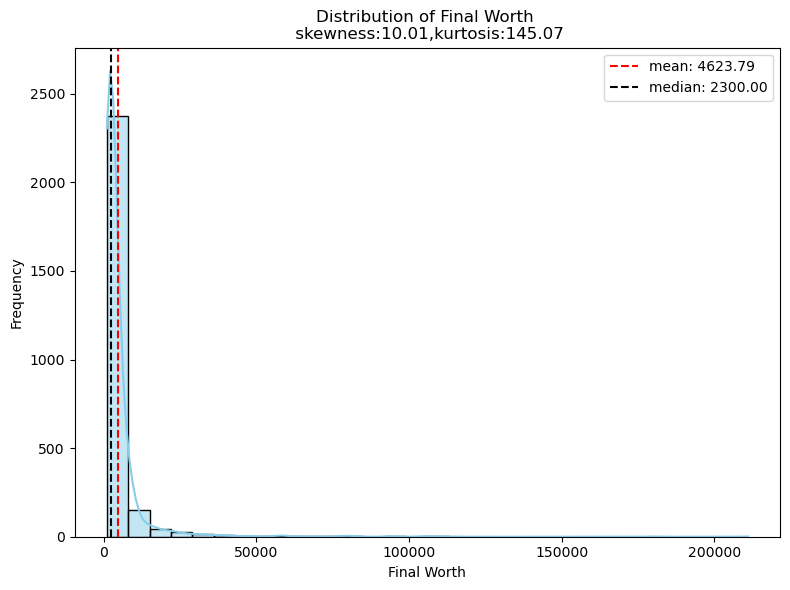

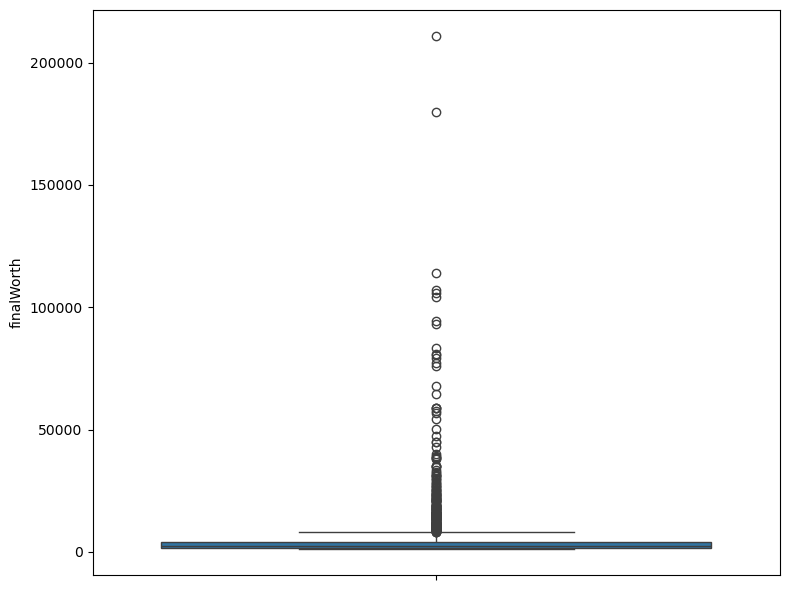

Number of extreme outliers identified: 194
1.4547633299130631


In [57]:
#histogram
plt.figure(figsize=(8,6))
sns.histplot(finalworth,kde = True , color = "skyblue", bins=30)#kde density estimation
plt.axvline(mean_finalworth,color = 'red',linestyle = "--",label=f'mean: {mean_finalworth:.2f}')
plt.axvline(median_finalworth,color = 'black',linestyle = "--",label=f'median: {median_finalworth:.2f}')
plt.title(f'Distribution of Final Worth \n skewness:{skewness_finalworth:.2f},kurtosis:{kurtosis_finalworth:.2f}')
plt.xlabel('Final Worth')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()
# Aslo draw a box plot
plt.figure(figsize=(8,6))
sns.boxplot(finalworth)
plt.tight_layout()
plt.show()

##Handling outliers since we have huge number of outliers and Vachan is awesome!!

Q1 = df['finalWorth'].quantile(0.25)
Q3 = df['finalWorth'].quantile(0.75)
IQR=Q3-Q1

lower_fence = Q1 - (3*IQR)
upper_fence = Q1 + (3*IQR)

df['is_extreme_outlier'] = (df['finalWorth'] > upper_fence) | (df['finalWorth']< lower_fence)

num_extreme_outliers = df['is_extreme_outlier'].sum()
print(f"Number of extreme outliers identified: {num_extreme_outliers}")


##Remove extreme outliers
df = df[df['is_extreme_outlier'] == False].copy()
finalworth = df['finalWorth']
mean_finalworth = finalworth.mean()
median_finalworth = finalworth.median()
skewness_finalworth = finalworth.skew()
print(skewness_finalworth)




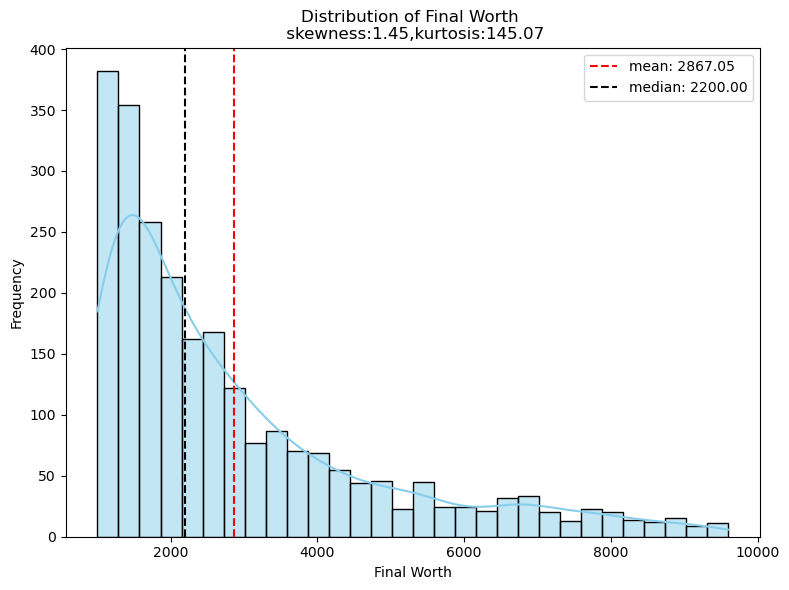

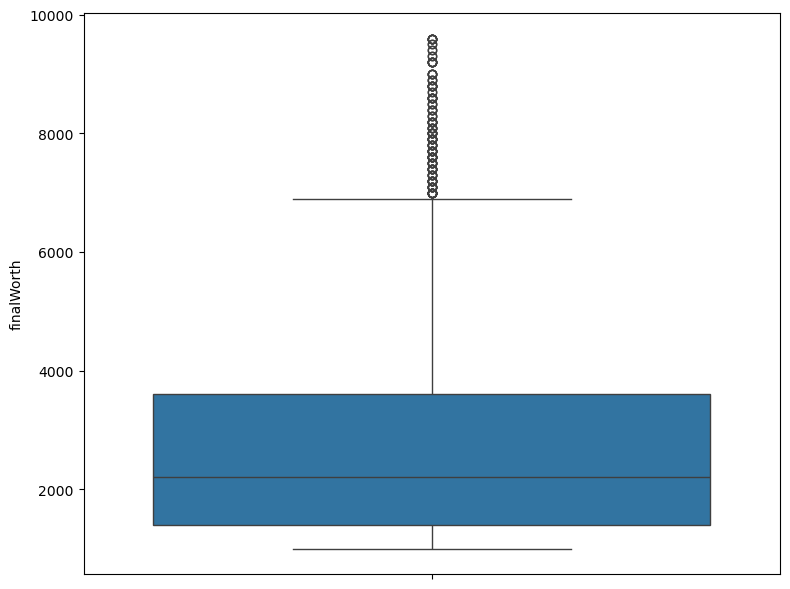

In [58]:
plt.figure(figsize=(8,6))
sns.histplot(finalworth,kde = True , color = "skyblue", bins=30)#kde density estimation
plt.axvline(mean_finalworth,color = 'red',linestyle = "--",label=f'mean: {mean_finalworth:.2f}')
plt.axvline(median_finalworth,color = 'black',linestyle = "--",label=f'median: {median_finalworth:.2f}')
plt.title(f'Distribution of Final Worth \n skewness:{skewness_finalworth:.2f},kurtosis:{kurtosis_finalworth:.2f}')
plt.xlabel('Final Worth')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(finalworth)
plt.tight_layout()
plt.show()

## Kurtosis describes the shape of the probability distribution of a real - valued random variable

   total_bill   tip  gender smoker  day    time  size  price_per_person  \
0       16.99  1.01  Female     No  Sun  Dinner     2              8.49   
1       10.34  1.66    Male     No  Sun  Dinner     3              3.45   
2       21.01  3.50    Male     No  Sun  Dinner     3              7.00   
3       23.68  3.31    Male     No  Sun  Dinner     2             11.84   
4       24.59  3.61  Female     No  Sun  Dinner     4              6.15   

           Payer Name     CC Number Payment ID  
0  Christy Cunningham  3.560330e+15    Sun2959  
1      Douglas Tucker  4.478070e+15    Sun4608  
2      Travis Walters  6.011810e+15    Sun4458  
3    Nathaniel Harris  4.676140e+15    Sun5260  
4        Tonya Carter  4.832730e+15    Sun2251  
Descriptive Statistics for the 'tip' column:
count    244.000000
mean       2.998279
std        1.383638
min        1.000000
25%        2.000000
50%        2.900000
75%        3.562500
max       10.000000
Name: tip, dtype: float64

 Additional statistics 

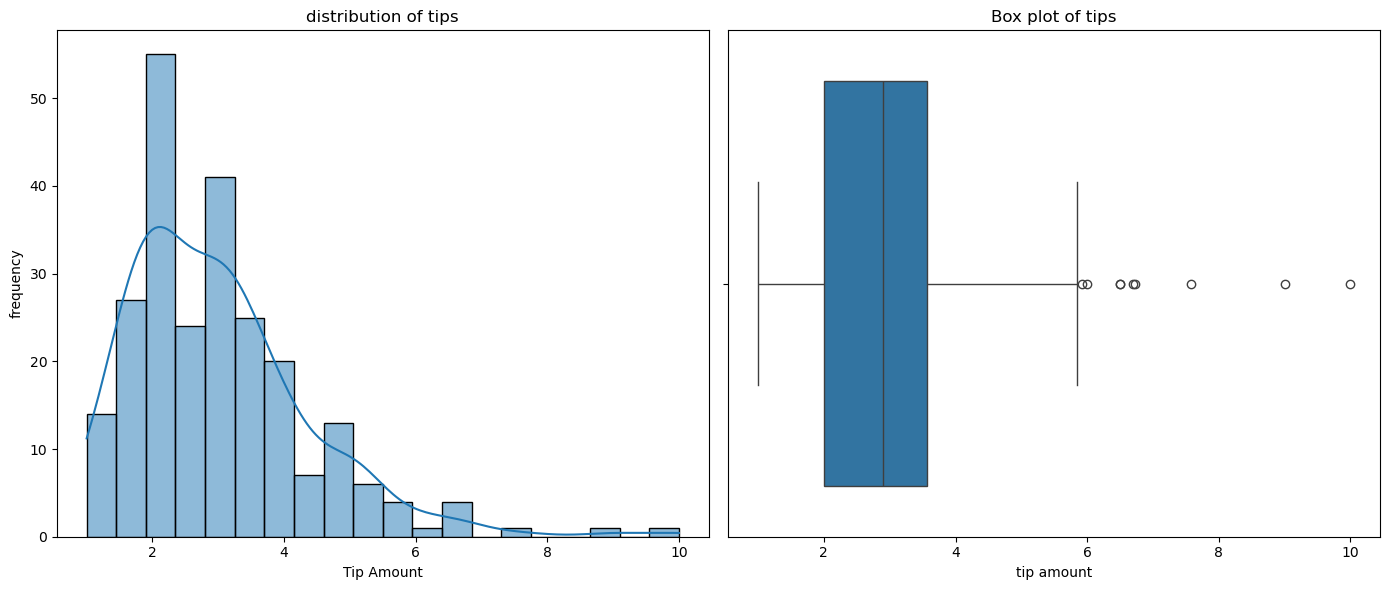

In [68]:
data = pd.read_csv("tips.csv")
print(data.head())

#Descriptive statistics for the 'tip' column
tip_stats = data['tip'].describe()
print("Descriptive Statistics for the \'tip\' column:")
print(tip_stats)

#Additional statistics
mean_tip = data['tip'].mean()
median_tip = data['tip'].median()
std_tip = data['tip'].std()
var_tip = data['tip'].var()
skew_tip = data['tip'].skew()
kurtosis_tip = data['tip'].kurtosis()
cv_tip= (std_tip/mean_tip)*100
q1 = np.percentile(data['tip'],25)
q2 = np.percentile(data['tip'],50)
q3 = np.percentile(data['tip'],75)

print("\n Additional statistics for the \'tip\' column: ")
print(f"Mean: {mean_tip}")
print(f"Median: {median_tip}")
print(f"Standard deviation: {std_tip}")
print(f"Variance: {var_tip}")
print(f"Skewness: {skew_tip}")
print(f"Kurtosis: {kurtosis_tip}")
print(f"Coefficient of Variation: {cv_tip} %")
print(f"Q1: {q1}")
print(f"Q2: {q2}")
print(f"Q3: {q3}")

#Plotting the distribution of the \'tip\' column
plt.figure(figsize = (14,6))
plt.subplot(1,2,1)
sns.histplot(data['tip'],bins= 20,kde = True)
plt.title("distribution of tips")
plt.xlabel("Tip Amount")
plt.ylabel("frequency")

# Box plot

plt.subplot(1,2,2)
sns.boxplot(x=data['tip'])
plt.title("Box plot of tips")
plt.xlabel("tip amount")
plt.tight_layout()
plt.show()

In [70]:
df = pd.read_csv("Gender,Height,Weight.csv")
print(df.head())

#separate data based on gender

df_male =df[df['Gender']=='Male']
df_female = df[df['Gender']=='Female']


#Calculate correaltion

corr_overall =df[['Height','Weight']].corr()
corr_male = df_male[['Height','Weight']].corr()
corr_female = df_female[['Height','Weight']].corr()

#Calculate covariance

cov_overall = df[['Height','Weight']].cov()
cov_male = df_male[['Height','Weight']].cov()
cov_female = df_female[['Height','Weight']].cov()

print("Overall Correlation between Height and Weight:  ")
print(corr_overall)
print("\nMale Correlation between Height and Weight:")
print(corr_male)
print("\nFemale Correlation between Height and Weight:")
print(corr_female)

print("Overall Covariance between Height and Weight:  ")
print(cov_overall)
print("\nMale Covariance between Height and Weight:")
print(cov_male)
print("\nFemale Covariance between Height and Weight:")
print(cov_female)


  Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Male  71.730978  220.042470
4   Male  69.881796  206.349801
Overall Correlation between Height and Weight:  
          Height    Weight
Height  1.000000  0.924756
Weight  0.924756  1.000000

Male Correaltion between Height and Weight:
          Height    Weight
Height  1.000000  0.862979
Weight  0.862979  1.000000

Female Correaltion between Height and Weight:
          Height    Weight
Height  1.000000  0.849609
Weight  0.849609  1.000000
Overall Covariance between Height and Weight:  
            Height       Weight
Height   14.803473   114.242656
Weight  114.242656  1030.951855

Male Covariance between Height and Weight:
           Height      Weight
Height   8.198843   48.879649
Weight  48.879649  391.294074

Female Covariance between Height and Weight:
           Height      Weight
Height   7.269947   43.576404
Weight  43.576404  361.854281


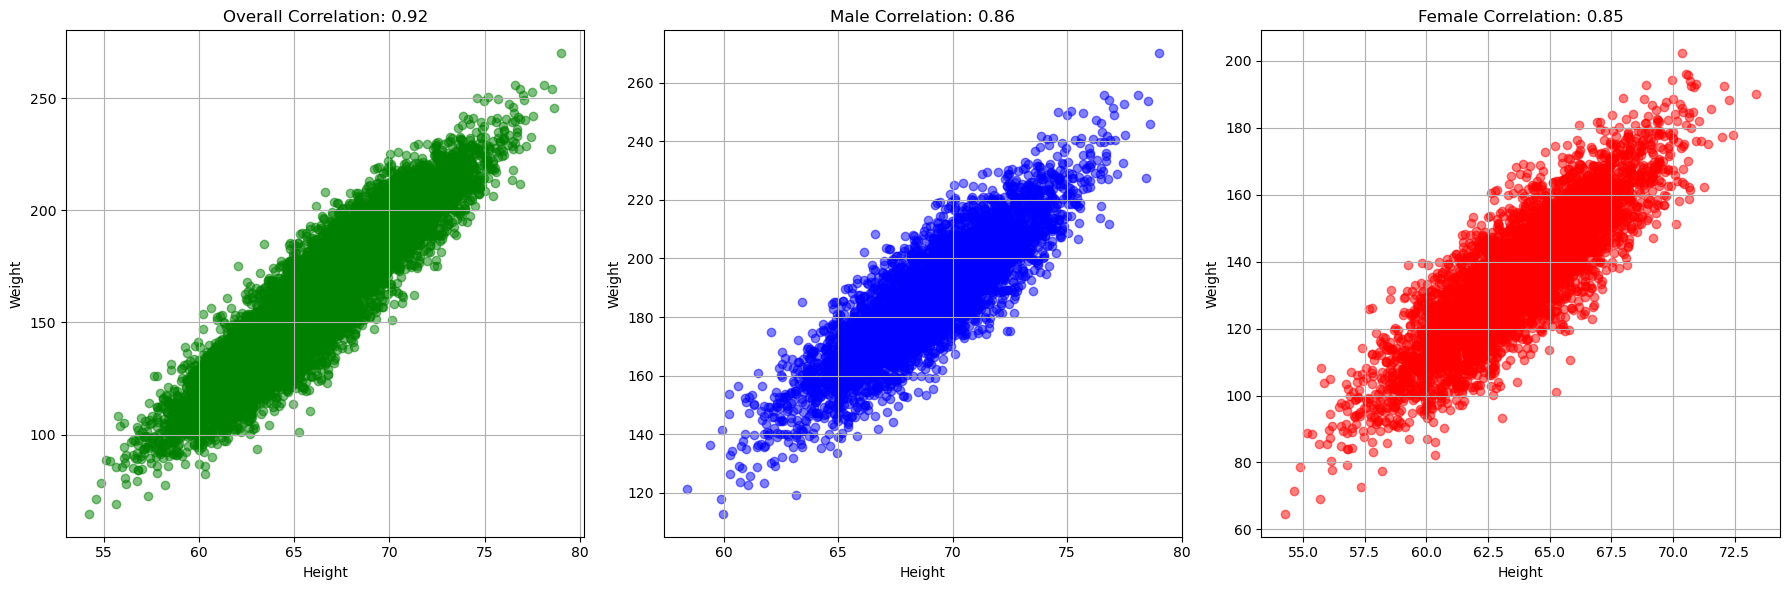

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Overall data plot
axes[0].scatter(df['Height'], df['Weight'], color='green', alpha=0.5)
axes[0].set_title(f"Overall Correlation: {corr_overall.loc['Height','Weight']:.2f}")
axes[0].set_xlabel('Height')
axes[0].set_ylabel('Weight')
axes[0].grid(True)

# Male data plot
axes[1].scatter(df_male['Height'], df_male['Weight'], color='blue', alpha=0.5)
axes[1].set_title(f"Male Correlation: {corr_male.loc['Height','Weight']:.2f}")
axes[1].set_xlabel('Height')
axes[1].set_ylabel('Weight')
axes[1].grid(True)

# Female data plot
axes[2].scatter(df_female['Height'], df_female['Weight'], color='red', alpha=0.5)
axes[2].set_title(f"Female Correlation: {corr_female.loc['Height','Weight']:.2f}")
axes[2].set_xlabel('Height')
axes[2].set_ylabel('Weight')
axes[2].grid(True)

plt.tight_layout()
plt.show()


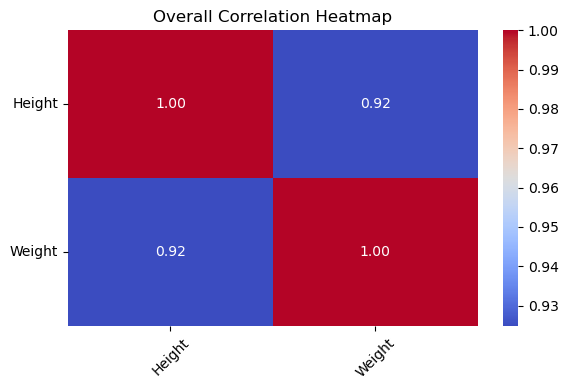

In [76]:
#HeatMAP

import seaborn as sns
plt.figure(figsize=(6,4))

sns.heatmap(corr_overall, annot = True, fmt = '.2f',cmap="coolwarm")
plt.title('Overall Correlation Heatmap')
plt.xticks(rotation=45) #label angle
plt.yticks(rotation=0)#label angle
plt.tight_layout()
plt.show()